In [2]:
!pip install tensorflow

     -------------------------------------- 390.0/390.0 MB 3.1 MB/s eta 0:00:00
     ---------------------------------------- 1.2/1.2 MB 5.0 MB/s eta 0:00:00
     ---------------------------------------- 15.9/15.9 MB 4.1 MB/s eta 0:00:00
     ---------------------------------------- 71.9/71.9 kB 3.9 MB/s eta 0:00:00
     -------------------------------------- 126.6/126.6 kB 3.8 MB/s eta 0:00:00
     ---------------------------------------- 26.4/26.4 MB 2.0 MB/s eta 0:00:00
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
     ------------------------------------ 431.5/431.5 kB 612.2 kB/s eta 0:00:00
     ------------------------------------ 133.7/133.7 kB 875.6 kB/s eta 0:00:00
     ---------------------------------------- 1.5/1.5 MB 665.5 kB/s eta 0:00:00
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
     ---------------------------------------- 3.0/3.0 MB 1.2 MB/s eta 0:00:00
     ---------------------------------------- 5.5/5.5 MB 2.9 MB/s eta 0:00:00
     -

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
scipy 1.10.0 requires numpy<1.27.0,>=1.19.5, but you have numpy 2.0.2 which is incompatible.
numba 0.56.4 requires numpy<1.24,>=1.18, but you have numpy 2.0.2 which is incompatible.


In [1]:
import tensorflow


In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.models import Model

# Set the paths
base_dir = 'data'
#corrosion_dir = os.path.join(base_dir, 'CORROSION')
no_corrosion_dir = os.path.join(base_dir, 'NOCORROSION')
corrosion_dir = os.path.join(base_dir, 'CORROSION')
# Parameters
img_height, img_width = 150, 150
batch_size = 32
epochs = 20

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Enhanced Data Preparation
data_gen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0, 1]
    validation_split=0.2,  # Split 20% of data for validation
    rotation_range=30,  # Randomly rotate images by up to 30 degrees
    width_shift_range=0.2,  # Randomly shift images horizontally by up to 20% of width
    height_shift_range=0.2,  # Randomly shift images vertically by up to 20% of height
    shear_range=0.2,  # Randomly shear images
    zoom_range=0.2,  # Randomly zoom in on images
    horizontal_flip=True,  # Randomly flip images horizontally
    fill_mode='nearest'  # Fill in missing pixels after transformations
)

# Training Data Generator
train_gen = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'  # Use the 'training' subset
)

# Validation Data Generator
val_gen = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'  # Use the 'validation' subset
)


Found 1456 images belonging to 2 classes.
Found 363 images belonging to 2 classes.


In [3]:
from PIL import Image

# Manually check a few images from corrosion directory
for img_file in os.listdir(corrosion_dir)[:5]:  # Check the first 5 images
    try:
        img_path = os.path.join(corrosion_dir, img_file)
        img = Image.open(img_path)
        img.verify()  # Verify the image
        print(f"{img_file} is a valid image.")
    except Exception as e:
        print(f"Error with {img_file}: {e}")

# Manually check a few images from no_corrosion directory
for img_file in os.listdir(no_corrosion_dir)[:5]:  # Check the first 5 images
    try:
        img_path = os.path.join(no_corrosion_dir, img_file)
        img = Image.open(img_path)
        img.verify()
        print(f"{img_file} is a valid image.")
    except Exception as e:
        print(f"Error with {img_file}: {e}")


000001.jpg is a valid image.
000004.jpg is a valid image.
000006.jpg is a valid image.
000007.jpg is a valid image.
000008.jpg is a valid image.
01401e0891.jpg is a valid image.
01a5aee1ab.jpg is a valid image.
037f0f3b6a.jpg is a valid image.
039219204d.jpg is a valid image.
03c66b67be.jpg is a valid image.


In [4]:
import os

# Define your directories
corrosion_dir = 'data/CORROSION'
no_corrosion_dir = 'data/NOCORROSION'

# Function to remove invalid files
def remove_invalid_files(directory):
    for file_name in os.listdir(directory):
        if file_name.startswith('._'):
            file_path = os.path.join(directory, file_name)
            try:
                os.remove(file_path)
                print(f"Removed invalid file: {file_path}")
            except Exception as e:
                print(f"Error removing {file_path}: {e}")

# Clean up both directories
remove_invalid_files(corrosion_dir)
remove_invalid_files(no_corrosion_dir)


In [6]:
for images, labels in train_gen:
 
    print("Batch labels:", labels)
    
     # Remove this line to see all batches


Batch labels: [0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1.
 1. 0. 1. 1. 0. 0. 1. 1.]
Batch labels: [1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1.
 0. 0. 1. 0. 0. 0. 0. 0.]
Batch labels: [1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1.
 1. 1. 0. 1. 1. 1. 0. 0.]
Batch labels: [0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 1. 1. 0. 1. 1. 1. 1. 1.]
Batch labels: [1. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1.
 1. 1. 1. 0. 0. 1. 1. 0.]
Batch labels: [1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0.
 1. 1. 0. 0. 0. 0. 1. 1.]
Batch labels: [1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1. 1. 1.
 0. 1. 0. 1. 0. 1. 1. 1.]
Batch labels: [1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1.
 1. 1. 0. 0. 1. 0. 0. 0.]
Batch labels: [1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0.
 0. 1. 1.

KeyboardInterrupt: 

In [6]:
# Model Function for Pre-trained models
def create_pretrained_model(model_name):
    if model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    elif model_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    elif model_name == 'EfficientNetB0':
        base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    else:
        raise ValueError("Model not recognized")

    # Freeze the base model
    for layer in base_model.layers:
        layer.trainable = False
    
    # Add custom classification layers
    model = models.Sequential()
    model.add(base_model)
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model Function for LeNet-5
def create_lenet_model():
    model = models.Sequential()
    model.add(layers.Conv2D(6, (5, 5), activation='tanh', input_shape=(img_height, img_width, 3)))
    model.add(layers.AveragePooling2D())
    model.add(layers.Conv2D(16, (5, 5), activation='tanh'))
    model.add(layers.AveragePooling2D())
    model.add(layers.Flatten())
    model.add(layers.Dense(120, activation='tanh'))
    model.add(layers.Dense(84, activation='tanh'))
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [45]:
models_to_test = ['VGG16', 'ResNet50', 'EfficientNetB0', 'LeNet5']
results = {}

# Train and evaluate each model with training time measurement
for model_name in models_to_test:
    print(f'Training {model_name} model...')
    start_time = time.time()
    
    if model_name in ['VGG16', 'ResNet50', 'EfficientNetB0']:
        model = create_pretrained_model(model_name)
    elif model_name == 'LeNet5':
        model = create_lenet_model()
    
    history = model.fit(train_gen, validation_data=val_gen, epochs=epochs)
    
    # Store results with training time
    end_time = time.time()
    results[model_name] = {'history': history, 'training_time': end_time - start_time}



Training VGG16 model...
Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.4467 - loss: 0.7300 - val_accuracy: 0.6253 - val_loss: 0.6609
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.6573 - loss: 0.6426 - val_accuracy: 0.7190 - val_loss: 0.6073
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.7685 - loss: 0.5768 - val_accuracy: 0.7300 - val_loss: 0.5738
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.7939 - loss: 0.5446 - val_accuracy: 0.7466 - val_loss: 0.5491
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.7933 - loss: 0.5176 - val_accuracy: 0.7576 - val_loss: 0.5310
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8042 - loss: 0.4909 - val_accuracy: 0.7686 - val_loss: 0.5168
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.7910 - loss: 0.4832 - val_accuracy: 0.7548 - val_loss: 0.5073
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.7952 - loss: 0.4766 - val_accu

C:\Users\daksh\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TypeError: AveragePooling2D.__init__() missing 1 required positional argument: 'pool_size'

In [47]:
model = create_pretrained_model('VGG16')

# Train the model
history = model.fit(train_gen, validation_data=val_gen, epochs=epochs)

# Save the model
model.save('vgg16_corrosion_model.h5')  # Save your trained model for later use


Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.5699 - loss: 0.6759 - val_accuracy: 0.6804 - val_loss: 0.6261
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.7440 - loss: 0.5947 - val_accuracy: 0.6997 - val_loss: 0.5899
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.7591 - loss: 0.5640 - val_accuracy: 0.7548 - val_loss: 0.5563
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.7728 - loss: 0.5349 - val_accuracy: 0.7576 - val_loss: 0.5352
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7797 - loss: 0.5124 - val_accuracy: 0.7631 - val_loss: 0.5194
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.8152 - loss: 0.4772 - val_accuracy: 0.7686 - val_loss: 0.5079
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.8314 - loss: 0.4634 - val_accuracy: 0.7658 - val_loss: 0.4996
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.7925 - loss: 0.4788 - val_accuracy: 0.7576 - val_loss:

In [49]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load the saved model
loaded_model = load_model('vgg16_corrosion_model.h5')

# Function to preprocess and predict the image
def preprocess_image(img_path):
    img = load_img(img_path, target_size=(img_height, img_width))  # Resize the image
    img_array = img_to_array(img)  # Convert to array
    img_array = img_array / 255.0  # Scale the image
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

def predict_image(model, img_path):
    img_array = preprocess_image(img_path)  # Preprocess the image
    prediction = model.predict(img_array)  # Make prediction
    predicted_class = 1 if prediction[0][0] > 0.5 else 0  # Binary classification
    return predicted_class

# Example usage
img_path = 'nocorrosion.jpg'  # Path to the image you want to predict
predicted_class = predict_image(loaded_model, img_path)
print(f'Predicted class: {"Corrosion" if predicted_class == 1 else "No Corrosion"}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
Predicted class: No Corrosion


In [57]:
img_path='corrosion.jpg'
predicted_class = predict_image(loaded_model, img_path)
print(f'Predicted class: {"Corrosion" if predicted_class == 1 else "No Corrosion"}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Predicted class: No Corrosion


In [12]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential


In [13]:
def create_inception_model():
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers:
        layer.trainable = False
    model = Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate and Train InceptionV3
inception_model = create_inception_model()
start_time = time.time()
history_inception = inception_model.fit(train_gen, validation_data=val_gen, epochs=epochs)
end_time = time.time()

print(f"InceptionV3 training time: {end_time - start_time:.2f} seconds")

C:\Users\daksh\anaconda3\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 830ms/step - accuracy: 0.6740 - loss: 0.6526 - val_accuracy: 0.7879 - val_loss: 0.4592
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 653ms/step - accuracy: 0.8697 - loss: 0.3261 - val_accuracy: 0.8292 - val_loss: 0.4094
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 29s 646ms/step - accuracy: 0.8885 - loss: 0.2803 - val_accuracy: 0.8512 - val_loss: 0.3644
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 651ms/step - accuracy: 0.9293 - loss: 0.1936 - val_accuracy: 0.8485 - val_loss: 0.3285
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 661ms/step - accuracy: 0.9394 - loss: 0.1850 - val_accuracy: 0.8650 - val_loss: 0.3267
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 31s 688ms/step - accuracy: 0.9579 - loss: 0.1545 - val_accuracy: 0.8705 - val_loss: 0.3112
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 664ms/step - accuracy: 0.9552 - loss: 0.1606 - val_accuracy: 0.8678 - val_loss: 0.3170
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 668ms/step - accuracy: 0.9672 - loss: 0.1276 - val_accu

In [9]:
!pip install keras-tuner


     -------------------------------------- 129.1/129.1 kB 3.8 MB/s eta 0:00:00


In [12]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
import time

# Hypermodel Definition
def build_model(hp):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers:
        layer.trainable = False  # Freeze the base model layers
    
    model = Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(hp.Float("dropout", 0.1, 0.5, step=0.1)),  # Tune dropout rate
        layers.Dense(hp.Int("units", 64, 256, step=64), activation='relu'),  # Tune dense layer units
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("learning_rate", [1e-3, 1e-4, 1e-5])),  # Tune learning rate
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Keras Tuner for Hyperparameter Tuning
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,  # Number of different hyperparameter combinations to try
    executions_per_trial=1,  # Number of times to train each model
    directory='tuner_logs',
    project_name='densenet_tuning'
)

# Search for the Best Hyperparameters
start_time = time.time()
tuner.search(train_gen, validation_data=val_gen, epochs=10)
end_time = time.time()

# Retrieve Best Hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Hyperparameters: Units: {best_hps.get('units')}, Dropout: {best_hps.get('dropout')}, Learning Rate: {best_hps.get('learning_rate')}")

# Train the Best Model
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(train_gen, validation_data=val_gen, epochs=epochs)

# Save the Best Model
best_model.save("best_densenet_model.h5")

print(f"Hyperparameter tuning and training completed in {end_time - start_time:.2f} seconds")


Trial 5 Complete [00h 10m 28s]
val_accuracy: 0.5702479481697083

Best val_accuracy So Far: 0.9008264541625977
Total elapsed time: 00h 38m 41s
Best Hyperparameters: Units: 192, Dropout: 0.30000000000000004, Learning Rate: 0.0001
Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.5374 - loss: 0.9095 - val_accuracy: 0.7410 - val_loss: 0.5270
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.7139 - loss: 0.5507 - val_accuracy: 0.8072 - val_loss: 0.4031
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.7936 - loss: 0.4473 - val_accuracy: 0.8567 - val_loss: 0.3705
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.8324 - loss: 0.3930 - val_accuracy: 0.8760 - val_loss: 0.3231
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.8441 - loss: 0.3572 - val_accuracy: 0.8815 - val_loss: 0.3063
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.8475 - loss: 0.3459 - val_accuracy: 0.8815 - val_loss: 0.2849
Epoch 7/10
46/46

Hyperparameter tuning and training completed in 2320.79 seconds


C:\Users\daksh\anaconda3\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - AUC: 0.5532 - Precision: 0.5055 - Recall: 0.4452 - accuracy: 0.5650 - loss: 0.8493

C:\Users\daksh\anaconda3\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


46/46 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - AUC: 0.5552 - Precision: 0.5071 - Recall: 0.4470 - accuracy: 0.5660 - loss: 0.8470 - val_AUC: 0.8270 - val_Precision: 0.7126 - val_Recall: 0.7212 - val_accuracy: 0.7410 - val_loss: 0.5237
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - AUC: 0.8392 - Precision: 0.7548 - Recall: 0.7322 - accuracy: 0.7588 - loss: 0.4880 - val_AUC: 0.9019 - val_Precision: 0.8313 - val_Recall: 0.8061 - val_accuracy: 0.8375 - val_loss: 0.3960
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - AUC: 0.9315 - Precision: 0.8500 - Recall: 0.8405 - accuracy: 0.8610 - loss: 0.3447 - val_AUC: 0.9215 - val_Precision: 0.7638 - val_Recall: 0.9212 - val_accuracy: 0.8347 - val_loss: 0.3829
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - AUC: 0.9210 - Precision: 0.8171 - Recall: 0.8420 - accuracy: 0.8466 - loss: 0.3587 - val_AUC: 0.9223 - val_Precision: 0.7989 - val_Recall: 0.8909 - val_accuracy: 0.8485 - val_loss: 0.3713
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step 

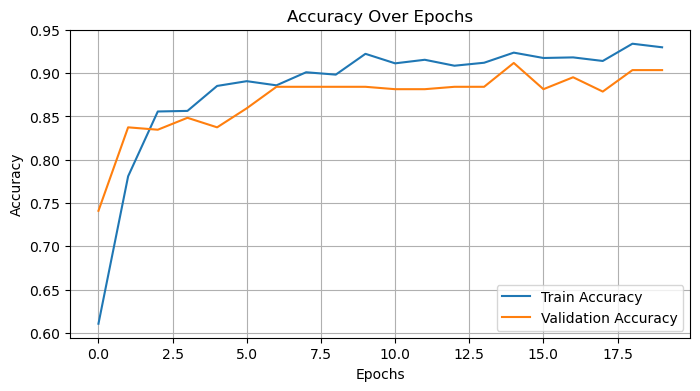

KeyError: 'precision'

<Figure size 800x400 with 0 Axes>

In [5]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# DenseNet121 Model
def create_densenet_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers:
        layer.trainable = False  # Freeze the base model layers
    model = Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(),
        loss='binary_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall', 'AUC']  # Additional metrics
    )
    return model

# Instantiate and Train DenseNet121
densenet_model = create_densenet_model()

start_time = time.time()
history_densenet = densenet_model.fit(
    train_gen, 
    validation_data=val_gen, 
    epochs=epochs
)
end_time = time.time()

print(f"DenseNet121 training time: {end_time - start_time:.2f} seconds")

# Plot Training and Validation Metrics
def plot_metrics(history):
    # Get metrics from history
    metrics = ['accuracy', 'precision', 'recall', 'auc']
    for metric in metrics:
        plt.figure(figsize=(8, 4))
        plt.plot(history.history[metric], label=f'Train {metric.capitalize()}')
        plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric.capitalize()}')
        plt.title(f'{metric.capitalize()} Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid()
        plt.show()

    # Plot Loss separately
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

# Call the function to plot metrics
plot_metrics(history_densenet)
